In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics

import warnings
warnings.filterwarnings("ignore")  

# 1. Data Loading

In [307]:
# Set the style of the plot
sns.set_style("whitegrid")

In [308]:
# Load data
data = pd.read_csv("data.csv")

In [309]:
# Rename columns
data.columns = ['customer_happiness', 'delivery_timeliness','order_accuracy','product_availability',
              'price_value_perception','courier_service_rating', 'app_usability']

In [310]:
# Basic overview of the data
data.head()

,customer_happiness,delivery_timeliness,order_accuracy,product_availability,price_value_perception,courier_service_rating,app_usability
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


In [311]:
data.tail()

,customer_happiness,delivery_timeliness,order_accuracy,product_availability,price_value_perception,courier_service_rating,app_usability
121,1,5,2,3,4,4,3
122,1,5,2,3,4,2,5
123,1,5,3,3,4,4,5
124,0,4,3,3,4,4,5
125,0,5,3,2,5,5,5


In [312]:
data.info()
data.describe(include = 'all')

<class 'pandas.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   customer_happiness      126 non-null    int64
 1   delivery_timeliness     126 non-null    int64
 2   order_accuracy          126 non-null    int64
 3   product_availability    126 non-null    int64
 4   price_value_perception  126 non-null    int64
 5   courier_service_rating  126 non-null    int64
 6   app_usability           126 non-null    int64
dtypes: int64(7)
memory usage: 7.0 KB


,customer_happiness,delivery_timeliness,order_accuracy,product_availability,price_value_perception,courier_service_rating,app_usability
count,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000
mean,0.547619,4.333333,2.531746,3.309524,3.746032,3.650794,4.253968
std,0.499714,0.800000,1.114892,1.023440,0.875776,1.147641,0.809311
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,4.000000,2.000000,3.000000,3.000000,3.000000,4.000000
50%,1.000000,5.000000,3.000000,3.000000,4.000000,4.000000,4.000000
75%,1.000000,5.000000,3.000000,4.000000,4.000000,4.000000,5.000000
max,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


# 2. Data Quality Checks

In [313]:
for column in data.columns:
    unique_values = data[column].value_counts()
    print(f"Unique values in '{column}': {unique_values}")

Unique values in 'customer_happiness': customer_happiness
1    69
0    57
Name: count, dtype: int64
Unique values in 'delivery_timeliness': delivery_timeliness
5    65
4    40
3    20
1     1
Name: count, dtype: int64
Unique values in 'order_accuracy': order_accuracy
3    42
2    34
1    27
4    17
5     6
Name: count, dtype: int64
Unique values in 'product_availability': product_availability
3    55
4    33
5    17
2    14
1     7
Name: count, dtype: int64
Unique values in 'price_value_perception': price_value_perception
4    53
3    41
5    25
2     5
1     2
Name: count, dtype: int64
Unique values in 'courier_service_rating': courier_service_rating
4    50
5    31
3    22
2    16
1     7
Name: count, dtype: int64
Unique values in 'app_usability': app_usability
5    57
4    47
3    20
2     1
1     1
Name: count, dtype: int64


## 2.1 Null check remove null rows.

In [314]:
# Count number of rows with null values
num_rows_with_nulls = data.isnull().any(axis=1).sum()
print(f"Number of rows with at least one null value: {num_rows_with_nulls}")

Number of rows with at least one null value: 0


In [315]:
# Drop rows with null values
data = data.dropna()

## 2.2. Duplicate check remove duplictae row.

In [316]:
# Count number of duplicate rows
num_duplicates = data.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 16


In [317]:
# Remove duplicate rows
data = data.drop_duplicates()

## 2.3 Type errors and impossible values.

In [318]:
# Counts of each unique value for customer_happiness
data["customer_happiness"].value_counts()

customer_happiness
1    56
0    54
Name: count, dtype: int64

In [319]:
# Check that all values for customer_happiness are either 0 or 1
valid_values = {0, 1}
invalid_count = (~data["customer_happiness"].isin(valid_values)).sum()
print(f"Number of rows with values other than 0 or 1: {invalid_count}")
if invalid_count == 0:
    print("All values in customer_happiness are either 0 or 1")

Number of rows with values other than 0 or 1: 0
All values in customer_happiness are either 0 or 1


In [320]:
# Drop rows where customer_happiness is not 0 or 1
data = data[data['customer_happiness'].isin({0, 1})]

In [321]:
feature_cols = [
    'delivery_timeliness',
    'order_accuracy',
    'product_availability',
    'price_value_perception',
    'courier_service_rating',
    'app_usability'
]

In [322]:
# Counts of each unique value for each feature
for col in feature_cols:
    print(f"Different values with count for {col}: {data[col].value_counts()}") 

Different values with count for delivery_timeliness: delivery_timeliness
5    55
4    36
3    18
1     1
Name: count, dtype: int64
Different values with count for order_accuracy: order_accuracy
3    37
2    30
1    23
4    15
5     5
Name: count, dtype: int64
Different values with count for product_availability: product_availability
3    50
4    27
5    14
2    13
1     6
Name: count, dtype: int64
Different values with count for price_value_perception: price_value_perception
4    46
3    35
5    22
2     5
1     2
Name: count, dtype: int64
Different values with count for courier_service_rating: courier_service_rating
4    41
5    27
3    19
2    16
1     7
Name: count, dtype: int64
Different values with count for app_usability: app_usability
5    48
4    40
3    20
2     1
1     1
Name: count, dtype: int64


In [323]:
# Drop rows where values for each feature are between 1 and 5
valid_values = {1, 2, 3, 4, 5}
valid_rows = data[feature_cols].isin(valid_values).all(axis=1)

#Filter data
data = data[valid_rows]

X = data[feature_cols]
y = data['customer_happiness']

# Verify ranges
for col in feature_cols:
    print(col, X[col].min(), X[col].max())
    
print(X.columns)    
print("All feature values are valid.")
print("Rows remaining:", len(data))

delivery_timeliness 1 5
order_accuracy 1 5
product_availability 1 5
price_value_perception 1 5
courier_service_rating 1 5
app_usability 1 5
Index(['delivery_timeliness', 'order_accuracy', 'product_availability',
       'price_value_perception', 'courier_service_rating', 'app_usability'],
      dtype='str')
All feature values are valid.
Rows remaining: 110


# 3. Univariate analysis.

## 3.1 Distributions, central tendency and shape.

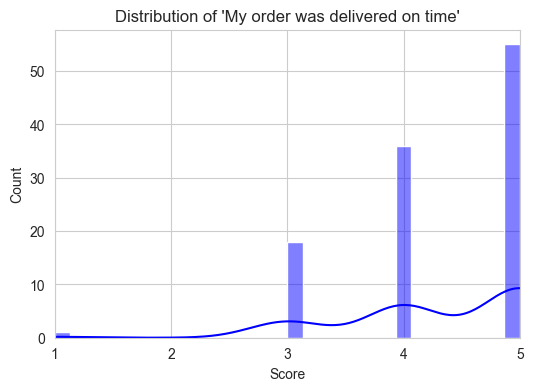

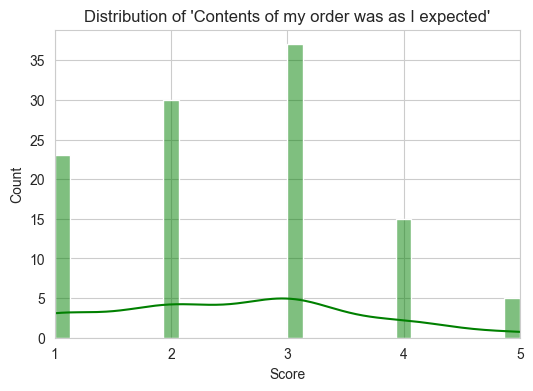

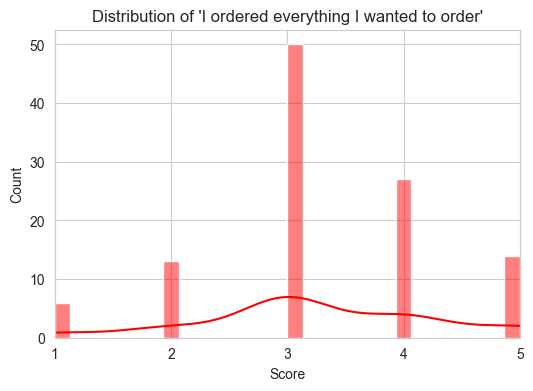

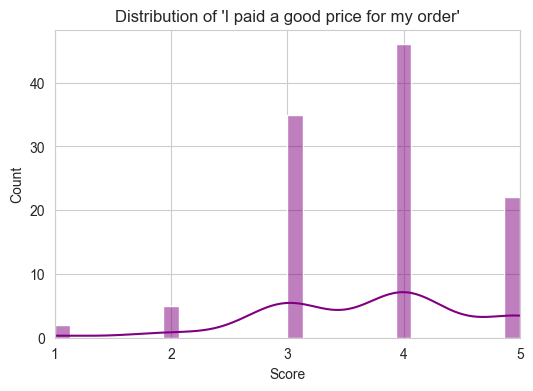

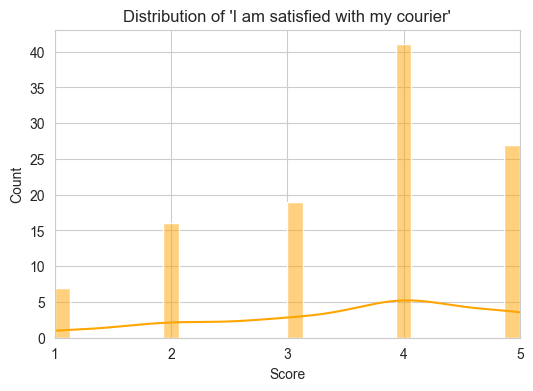

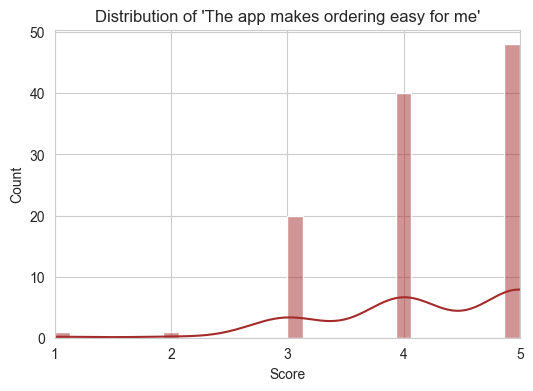

In [324]:
# Distributions for all features
features = ['delivery_timeliness', 'order_accuracy', 'product_availability', 'price_value_perception', 'courier_service_rating', 'app_usability']
titles = [
    "Distribution of 'My order was delivered on time'",
    "Distribution of 'Contents of my order was as I expected'",
    "Distribution of 'I ordered everything I wanted to order'",
    "Distribution of 'I paid a good price for my order'",
    "Distribution of 'I am satisfied with my courier'",
    "Distribution of 'The app makes ordering easy for me'"
]
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']

for feature, title, color in zip(features, titles, colors):
    plt.figure(figsize=(6, 4))
    sns.histplot(data[feature].dropna(), kde=True, bins=30, color=color)
    plt.title(title)
    plt.xlabel("Score")
    plt.xticks([1, 2, 3, 4, 5])
    plt.xlim(1, 5)
    plt.show()

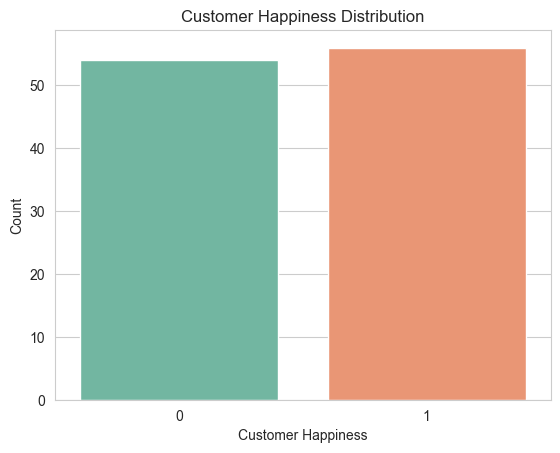

In [325]:
# Countplot for Categorical column
sns.countplot(x="customer_happiness", data=data, palette="Set2")
plt.title("Customer Happiness Distribution")
plt.xlabel("Customer Happiness")
plt.ylabel("Count")
plt.show()

# 4. Bivariate analysis.

## 4.1 Relationship each curtomer happiness and each feature.

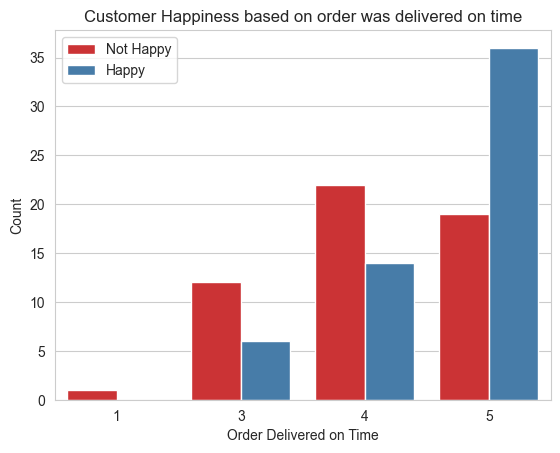

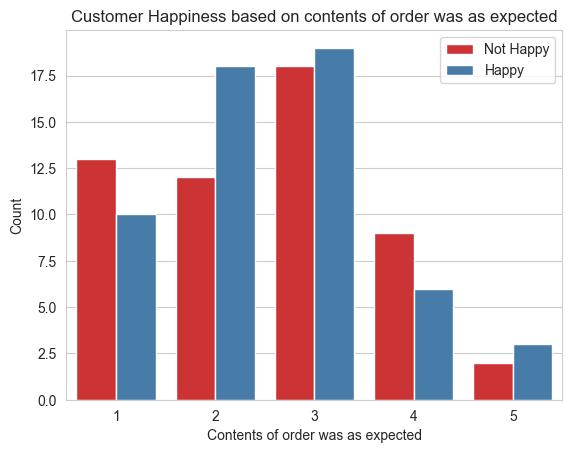

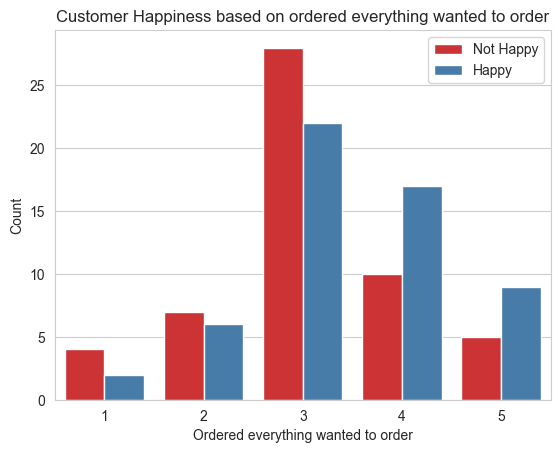

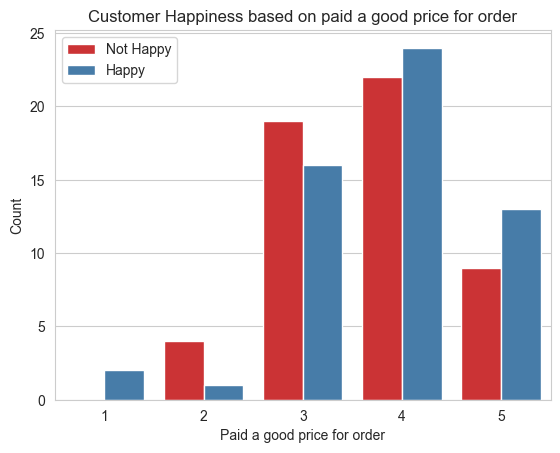

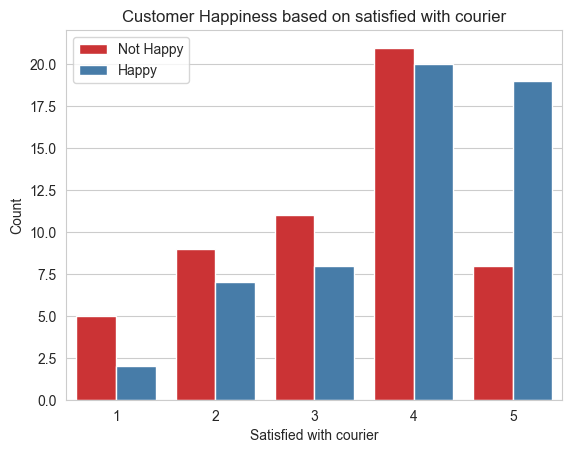

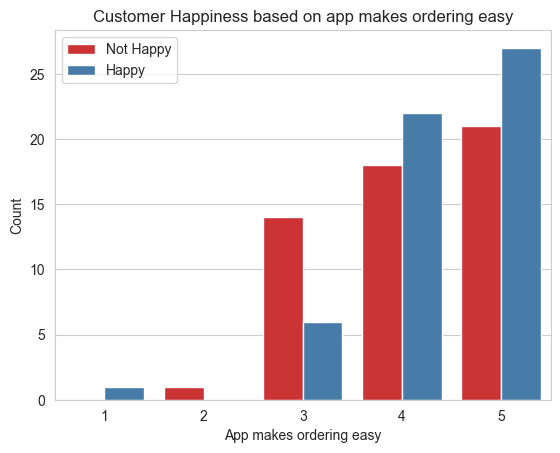

In [326]:
# Bivariate analysis: Relationship between each feature and customer_happiness
features = ['delivery_timeliness', 'order_accuracy', 'product_availability', 'price_value_perception', 'courier_service_rating', 'app_usability']
titles = [
    "Customer Happiness based on order was delivered on time",
    "Customer Happiness based on contents of order was as expected",
    "Customer Happiness based on ordered everything wanted to order",
    "Customer Happiness based on paid a good price for order",
    "Customer Happiness based on satisfied with courier",
    "Customer Happiness based on app makes ordering easy"
]
xlabels = [
    "Order Delivered on Time",
    "Contents of order was as expected",
    "Ordered everything wanted to order",
    "Paid a good price for order",
    "Satisfied with courier",
    "App makes ordering easy"
]

for feature, title, xlabel in zip(features, titles, xlabels):
    sns.countplot(x=feature, hue="customer_happiness", data=data, palette="Set1")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.legend(labels=['Not Happy', 'Happy'])
    plt.show()

## 4.2. Relationship between each feature.

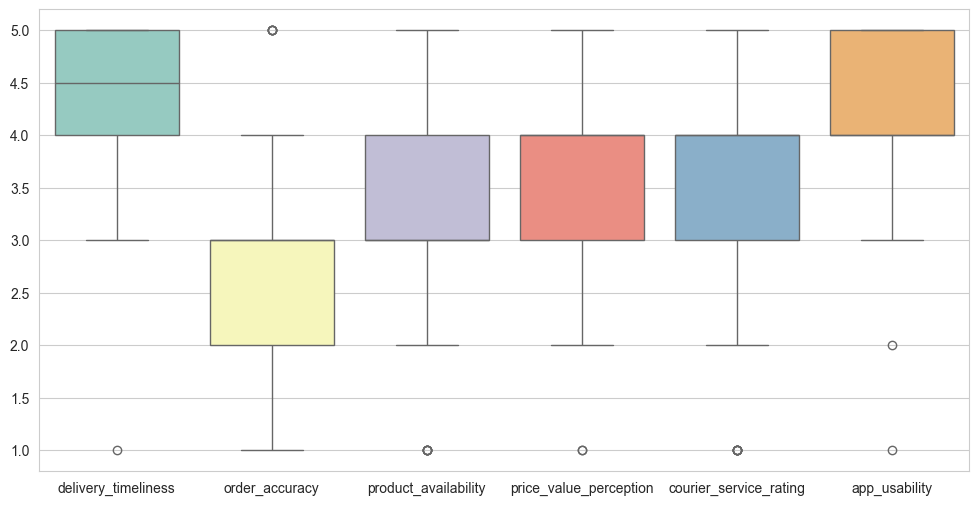

In [327]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data[features], palette="Set3")
plt.show()

# 5. Multivariate analysis.

## 5.1 All pairwise correlation.

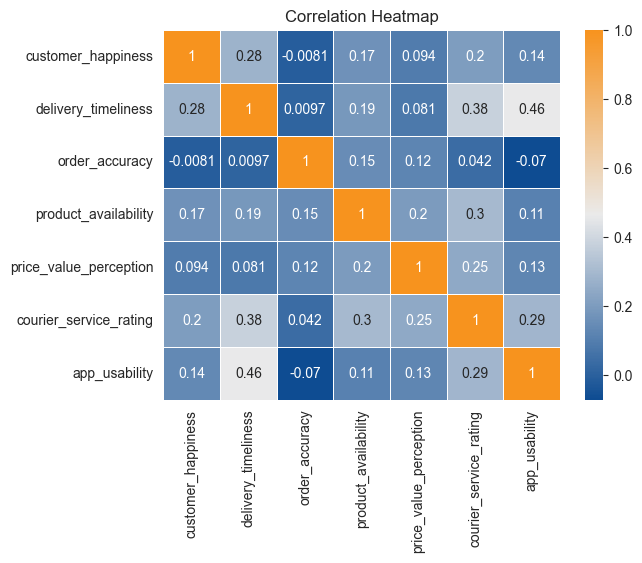

<Figure size 1600x1000 with 0 Axes>

In [328]:
from matplotlib.colors import LinearSegmentedColormap

colors_sentiment = ["#0E4C92", "#EAEAEA", "#F7931E"]
cmap_sentiment = LinearSegmentedColormap.from_list("sentiment", colors_sentiment)
ax = sns.heatmap(data.corr(method='kendall'), annot=True, cmap=cmap_sentiment, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.figure(figsize=(16, 10))
plt.show()

# 6. Split Training and Testing Data

In [329]:
from sklearn.model_selection import train_test_split

# Extract features and target variable
X = data.drop(columns=['customer_happiness'])
y = data['customer_happiness']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [330]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((88, 6), (88,), (22, 6), (22,))

In [331]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# 7. Model building.

## 7.1 Logistic Regression.

In [350]:
# Train a linear regression model
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [351]:
# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [352]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred, target_names=['Unhappy', 'Happy']))

Accuracy: 0.6363636363636364
ROC-AUC: 0.8166666666666667

Confusion Matrix
[[6 6]
 [2 8]]

Classification Report
              precision    recall  f1-score   support

     Unhappy       0.75      0.50      0.60        12
       Happy       0.57      0.80      0.67        10

    accuracy                           0.64        22
   macro avg       0.66      0.65      0.63        22
weighted avg       0.67      0.64      0.63        22



In [353]:
# Finding the most influential features
# Positive coefficient → increases probability of class 1.
# Negative coefficient → decreases probability of class 1.
# Larger magnitude → stronger influence.

lr_coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient_LR": model.coef_[0]
})

lr_coef_df["AbsCoefficient_LR"] = (
    lr_coef_df["Coefficient_LR"].abs()
)

lr_coef_df = lr_coef_df.sort_values(
    "AbsCoefficient_LR",
    ascending=False
)

print(lr_coef_df)

                  Feature  Coefficient_LR  AbsCoefficient_LR
4  courier_service_rating        0.310606           0.310606
0     delivery_timeliness        0.170985           0.170985
2    product_availability        0.106548           0.106548
3  price_value_perception        0.080386           0.080386
1          order_accuracy       -0.043489           0.043489
5           app_usability       -0.006675           0.006675


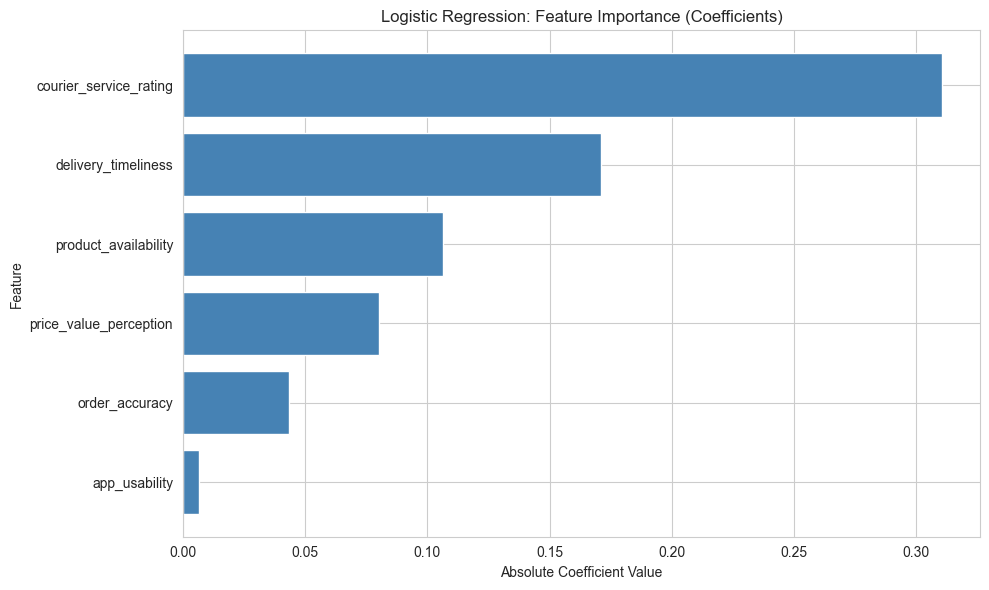

In [354]:

# Plotting feature importance (coefficients)
plt.figure(figsize=(10, 6))

plt.barh(
    lr_coef_df["Feature"],
    lr_coef_df["AbsCoefficient_LR"],
    color='steelblue'
)

plt.gca().invert_yaxis()

plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.title("Logistic Regression: Feature Importance (Coefficients)")

plt.tight_layout()
plt.show()


In [355]:
# Odds ratios
# Odds Ratio > 1 → increases odds of class 1.
# Odds Ratio < 1 → decreases odds of class 1.
# Odds Ratio = 1.5 → 50% increase in odds for a one-unit increase in the feature.
# Odds Ratio = 0.5 → 50% decrease in odds.

odds_ratios = pd.DataFrame({
    "Feature": X.columns,
    "OddsRatio": np.exp(model.coef_[0])
})

print(odds_ratios.sort_values("OddsRatio", ascending=False))

                  Feature  OddsRatio
4  courier_service_rating   1.364252
0     delivery_timeliness   1.186472
2    product_availability   1.112432
3  price_value_perception   1.083705
5           app_usability   0.993347
1          order_accuracy   0.957443


## 7.2 Random Forest.

In [361]:
# Training the model.
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [362]:
# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [363]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred, target_names=['Unhappy', 'Happy']))

Accuracy: 0.5909090909090909
ROC-AUC: 0.5666666666666667

Confusion Matrix
[[5 7]
 [2 8]]

Classification Report
              precision    recall  f1-score   support

     Unhappy       0.71      0.42      0.53        12
       Happy       0.53      0.80      0.64        10

    accuracy                           0.59        22
   macro avg       0.62      0.61      0.58        22
weighted avg       0.63      0.59      0.58        22



In [374]:
# Feature Importance
# Importance = 0.10 means shuffling that feature reduced ROC-AUC by about 0.10.
# Larger drops indicate more influential features.

from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

rf_perm_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance_RF": result.importances_mean
})

perm_importance = rf_perm_importance.sort_values(
    "Importance_RF",
    ascending=False
)

print(perm_importance)

                  Feature  Importance_RF
0     delivery_timeliness       0.117500
5           app_usability       0.016667
4  courier_service_rating       0.000833
2    product_availability       0.000833
3  price_value_perception      -0.002500
1          order_accuracy      -0.060000


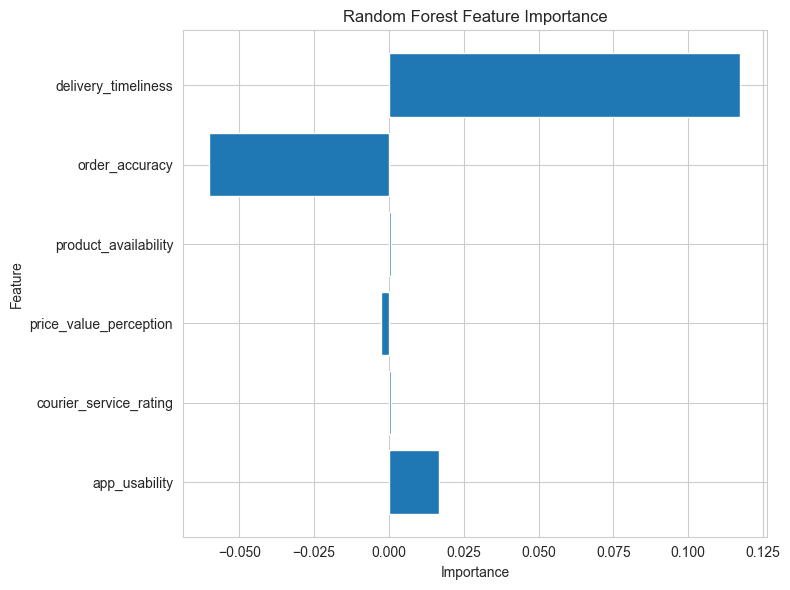

In [375]:
# Plotting feature importance
top_features = rf_perm_importance.head(15)

plt.figure(figsize=(8, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance_RF"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

## 7.3 XGBoost (Gradient Boosting).

In [367]:
from xgboost import XGBClassifier

# Build model
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [368]:
# Predict
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [369]:
# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred, target_names=['Unhappy', 'Happy']))

Accuracy: 0.5
ROC AUC: 0.575

Confusion Matrix
[[5 7]
 [4 6]]

Classification Report
              precision    recall  f1-score   support

     Unhappy       0.56      0.42      0.48        12
       Happy       0.46      0.60      0.52        10

    accuracy                           0.50        22
   macro avg       0.51      0.51      0.50        22
weighted avg       0.51      0.50      0.50        22



In [370]:
# Feature importance
xgb_importances_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance_XGB": model.feature_importances_
})

xgb_importances_df = xgb_importances_df.sort_values(
    by="Importance_XGB",
    ascending=False
)

print(xgb_importances_df.head(20))

                  Feature  Importance_XGB
0     delivery_timeliness        0.189921
2    product_availability        0.165492
4  courier_service_rating        0.164842
1          order_accuracy        0.163768
5           app_usability        0.162193
3  price_value_perception        0.153784


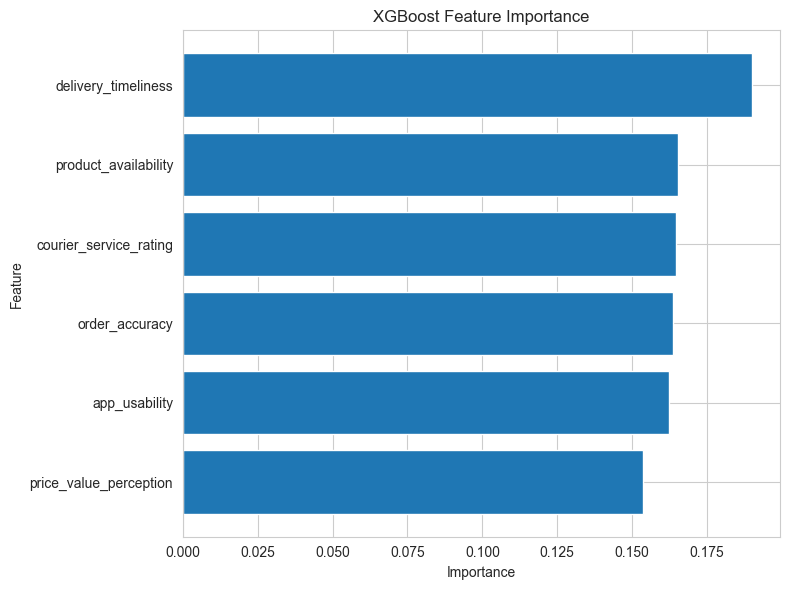

In [372]:
# Plotting feature importance
top_features = xgb_importances_df.head(15)

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance_XGB"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()

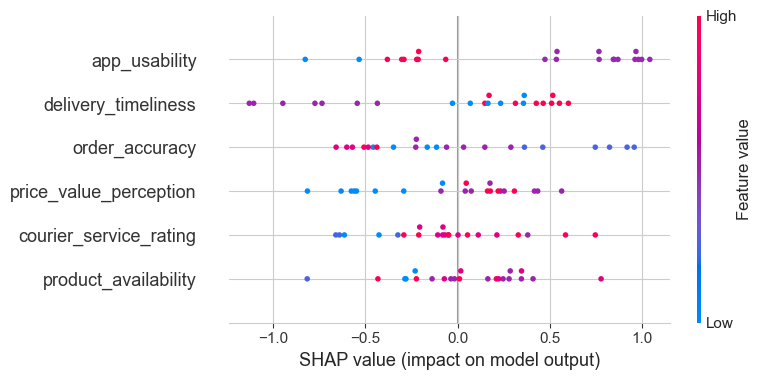

In [348]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

# 8. Model comparison.

In [ ]:
# Convert importance values to ranks

lr_coef_df['Rank_LR'] = lr_coef_df["AbsCoefficient_LR"].rank(ascending=False, method='dense').astype(int)

rf_perm_importance['Rank_RF'] = rf_perm_importance["Importance_RF"].rank(ascending=False, method='dense').astype(int)

xgb_importances_df['Rank_XGB'] = xgb_importances_df["Importance_XGB"].rank(ascending=False, method='dense').astype(int)

print(lr_coef_df.head(10))
print("\n", rf_perm_importance.head(10))
print("\n", xgb_importances_df.head(10))

                  Feature  Coefficient_LR  AbsCoefficient_LR  Rank_LR
4  courier_service_rating        0.310606           0.310606        1
0     delivery_timeliness        0.170985           0.170985        2
2    product_availability        0.106548           0.106548        3
3  price_value_perception        0.080386           0.080386        4
1          order_accuracy       -0.043489           0.043489        5
5           app_usability       -0.006675           0.006675        6

                   Feature  Importance_RF  Rank_RF
0     delivery_timeliness       0.117500        1
1          order_accuracy      -0.060000        6
2    product_availability       0.000833        4
3  price_value_perception      -0.002500        5
4  courier_service_rating       0.000833        3
5           app_usability       0.016667        2

                   Feature  Importance_XGB  Rank_XGB
0     delivery_timeliness        0.189921         1
2    product_availability        0.165492         2


In [388]:
importance_compare = (
    lr_coef_df[['Feature','Rank_LR']]
    .merge(
        rf_perm_importance[['Feature','Rank_RF']],
        on='Feature'
    )
    .merge(
        xgb_importances_df[['Feature','Rank_XGB']],
        on='Feature'
    )
)

importance_compare['Average_Rank'] = (
    importance_compare[
        ['Rank_LR','Rank_RF','Rank_XGB']
    ].mean(axis=1)
)

importance_compare.sort_values(
    'Average_Rank'
)

,Feature,Rank_LR,Rank_RF,Rank_XGB,Average_Rank
1,delivery_timeliness,2.0,1.0,1.0,1.333333
0,courier_service_rating,1.0,3.0,3.0,2.333333
2,product_availability,3.0,4.0,2.0,3.000000
5,app_usability,6.0,2.0,5.0,4.333333
3,price_value_perception,4.0,5.0,6.0,5.000000
4,order_accuracy,5.0,6.0,4.0,5.000000


In [ ]:
# Plot the feature ranking across models
rank_plot = importance_compare.sort_values('Average_Rank')
rank_plot['Feature'] = pd.Categorical(
    rank_plot['Feature'],
    categories=rank_plot['Feature'],
    ordered=True
)

plt.figure(figsize=(12, 7))
y = np.arange(len(rank_plot))
height = 0.25

plt.barh(y - height, rank_plot['Rank_LR'], height, label='Logistic Regression')
plt.barh(y, rank_plot['Rank_RF'], height, label='Random Forest')
plt.barh(y + height, rank_plot['Rank_XGB'], height, label='XGBoost')

plt.yticks(y, rank_plot['Feature'])
plt.gca().invert_yaxis()
plt.xlabel('Rank (1 = highest importance)')
plt.title('Feature ranking comparison across models')
plt.legend()
plt.tight_layout()
plt.show()

# Plot average rank separately
plt.figure(figsize=(10, 6))
plt.barh(rank_plot['Feature'], rank_plot['Average_Rank'], color='teal')
plt.gca().invert_yaxis()
plt.xlabel('Average Rank')
plt.title('Average feature rank across models')
plt.tight_layout()
plt.show()


# 9. Data visualization of prediction results.

In [29]:
plt.figure(figsize=(4, 3))
plt.scatter(x=y_train, y=y_lr_train_pred, alpha=0.3)

plt.title("Actual vs Predicted Customer Happiness (Linear Regression)")
plt.xlabel("Actual Customer Happiness")
plt.ylabel("Predicted Customer Happiness")

z = np.polyfit(y_train, y_lr_train_pred, 1)
plt.plot()  

NameError: name 'y_lr_train_pred' is not defined

<Figure size 400x300 with 0 Axes>